In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/animatronbot/mnist-digit-recognizer/train.csv


In [2]:
from matplotlib import pyplot as plt

In [3]:
data = pd.read_csv('/kaggle/input/datasets/animatronbot/mnist-digit-recognizer/train.csv')

In [4]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data = np.array(data)
m,n = data.shape
np.random.shuffle(data)

data_dev = data[0 : 1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train /255
_, m_train = X_train.shape

In [6]:
def init_params():
    W1 = np.random.rand(10,784)-0.5
    b1 = np.random.rand(10,1)-0.5
    W2 = np.random.rand(10,10)-0.5
    b2 = np.random.rand(10,1)-0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(0,Z)

def deri_ReLU(Z):
    return Z >0

def softmax(Z):
    return np.exp(Z) / sum(np.exp(Z))

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def back_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m =Y.size
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * deri_ReLU(Z1)
    dW1 = 1 / m * dZ2.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1,b1, W2,b2, dW1,db1,dW2,db2,alpha):
    W1 = W1 - dW1 * alpha
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2
    

In [7]:
def get_predictions(A2):
    return np.argmax(A2,0)

def get_accuracy(prediction,Y):
    print(prediction, Y)
    return np.sum(prediction ==Y )/Y.size

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2,W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i%10 == 0 :
            print("Iteration: ",i)
            print("Accuracy: ",get_accuracy(get_predictions(A2),Y))
    return W1, b1, W2, b2

In [8]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1 )

Iteration:  0
[6 4 5 ... 3 4 4] [2 4 6 ... 5 5 7]
Accuracy:  0.15517073170731707
Iteration:  10
[6 2 6 ... 6 4 4] [2 4 6 ... 5 5 7]
Accuracy:  0.2049512195121951
Iteration:  20
[6 2 6 ... 6 2 2] [2 4 6 ... 5 5 7]
Accuracy:  0.31114634146341463
Iteration:  30
[6 2 6 ... 6 2 3] [2 4 6 ... 5 5 7]
Accuracy:  0.4473170731707317
Iteration:  40
[6 2 6 ... 6 2 7] [2 4 6 ... 5 5 7]
Accuracy:  0.5111463414634146
Iteration:  50
[6 4 6 ... 6 2 7] [2 4 6 ... 5 5 7]
Accuracy:  0.5768048780487804
Iteration:  60
[6 4 6 ... 4 2 7] [2 4 6 ... 5 5 7]
Accuracy:  0.6254634146341463
Iteration:  70
[6 4 6 ... 7 2 7] [2 4 6 ... 5 5 7]
Accuracy:  0.657609756097561
Iteration:  80
[6 4 6 ... 7 2 7] [2 4 6 ... 5 5 7]
Accuracy:  0.6882195121951219
Iteration:  90
[6 4 6 ... 7 5 7] [2 4 6 ... 5 5 7]
Accuracy:  0.7166585365853658
Iteration:  100
[6 4 6 ... 5 5 7] [2 4 6 ... 5 5 7]
Accuracy:  0.7391463414634146
Iteration:  110
[6 4 6 ... 5 5 7] [2 4 6 ... 5 5 7]
Accuracy:  0.755390243902439
Iteration:  120
[6 4 6 ... 

In [9]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(idx, W1, b1, W2, b2):
    curr_img = X_train[: , idx, None]
    prediction = make_predictions(X_train[: , idx, None], W1, b1, W2, b2)
    label = Y_train[idx]
    print("Prediction: ",prediction)
    print("Label ",label)

    current_image = curr_img.reshape((28,28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation = 'nearest')
    plt.show()
    

Prediction:  [2]
Label  2


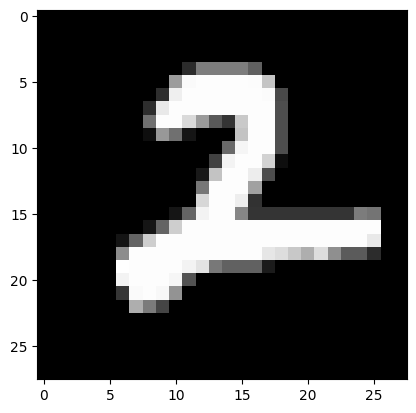

Prediction:  [4]
Label  4


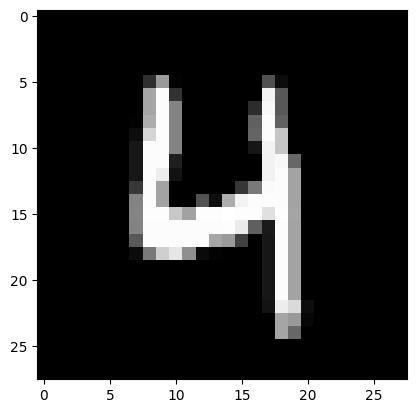

Prediction:  [6]
Label  6


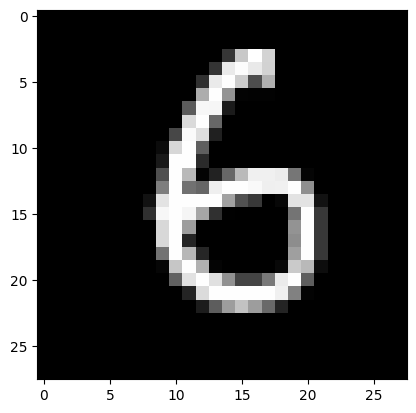

Prediction:  [9]
Label  2


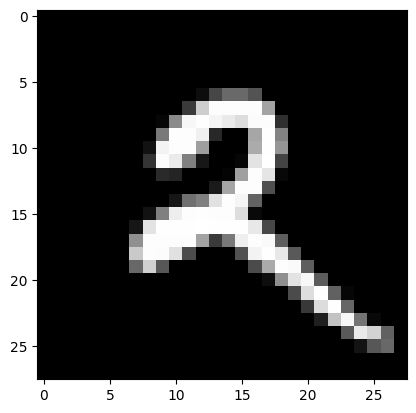

In [10]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

In [11]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[4 2 7 4 8 1 6 2 1 9 5 6 6 1 4 4 4 0 7 0 1 5 1 2 8 4 2 3 6 4 0 7 0 3 5 5 9
 2 2 8 9 2 6 9 4 8 6 4 2 8 9 9 4 0 2 8 4 0 7 9 8 7 6 5 6 7 8 1 2 3 6 3 4 7
 1 3 1 4 0 6 9 1 2 1 4 7 1 6 8 6 9 0 2 9 7 4 1 0 9 5 8 9 9 2 3 3 7 3 7 7 3
 9 1 0 9 9 2 1 0 3 8 4 4 1 2 9 8 3 0 8 7 6 2 7 6 9 8 5 5 1 4 4 1 7 3 9 0 4
 8 2 6 7 3 4 3 7 4 7 0 6 3 2 6 6 9 5 7 5 3 0 0 4 1 1 2 3 1 8 4 8 4 6 9 6 8
 2 4 8 2 7 5 6 2 2 1 3 7 1 5 9 9 3 7 0 2 3 6 8 7 4 8 0 9 0 9 8 8 0 6 6 6 2
 7 9 5 2 8 7 0 7 3 0 6 4 7 4 5 9 9 3 5 8 7 7 0 0 3 4 8 1 9 5 9 2 1 4 4 0 5
 0 8 9 0 7 7 3 7 7 5 0 1 8 0 3 2 3 7 2 3 8 0 9 0 5 0 9 0 7 9 7 1 4 0 4 3 4
 4 5 2 3 4 2 3 1 6 2 2 4 2 0 5 1 0 0 2 6 3 1 7 6 3 1 6 6 2 3 7 0 8 7 9 8 9
 1 5 9 6 7 7 3 4 6 7 2 6 2 9 7 7 0 3 2 5 7 8 3 3 7 3 8 2 9 3 2 9 2 5 9 9 5
 3 4 5 3 6 1 1 6 8 7 2 4 7 5 4 9 5 1 3 4 8 3 4 0 6 8 1 9 2 1 8 1 7 9 7 0 4
 0 4 8 1 8 8 2 0 1 2 3 4 6 8 0 5 0 2 6 1 8 3 1 0 6 2 9 3 4 9 4 7 8 6 1 9 0
 4 8 3 0 7 2 0 0 5 7 7 8 5 4 8 7 4 9 0 0 2 6 0 3 7 5 7 1 0 1 7 7 1 9 2 9 0
 5 6 9 2 0 9 8 8 0 8 0 9 

np.float64(0.864)